# Explore here

In [32]:
# PASO 1: CARGO DEL CONJUNTO DE DATOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("📦 Cargando librerías... ✅")

# Carga del dataset original (Pima Indians Diabetes)
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
df = pd.read_csv(url)

print("\n✅ Dataset cargado correctamente")
print(f"📐 Shape: {df.shape}")
print(f"\n🔍 Primeras filas:")
df.head()

📦 Cargando librerías... ✅

✅ Dataset cargado correctamente
📐 Shape: (768, 9)

🔍 Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
# EDA rápido 

print("📊 Información general del dataset:")
print(df.info())

print("\n📈 Estadísticas descriptivas:")
print(df.describe())

print("\n🔎 Valores nulos:")
print(df.isnull().sum())

print("\n🎯 Distribución de la variable objetivo:")
print(df['Outcome'].value_counts())
print(f"\nPorcentaje positivos (diabéticos): {df['Outcome'].mean()*100:.1f}%")

📊 Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

📈 Estadísticas descriptivas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.89453

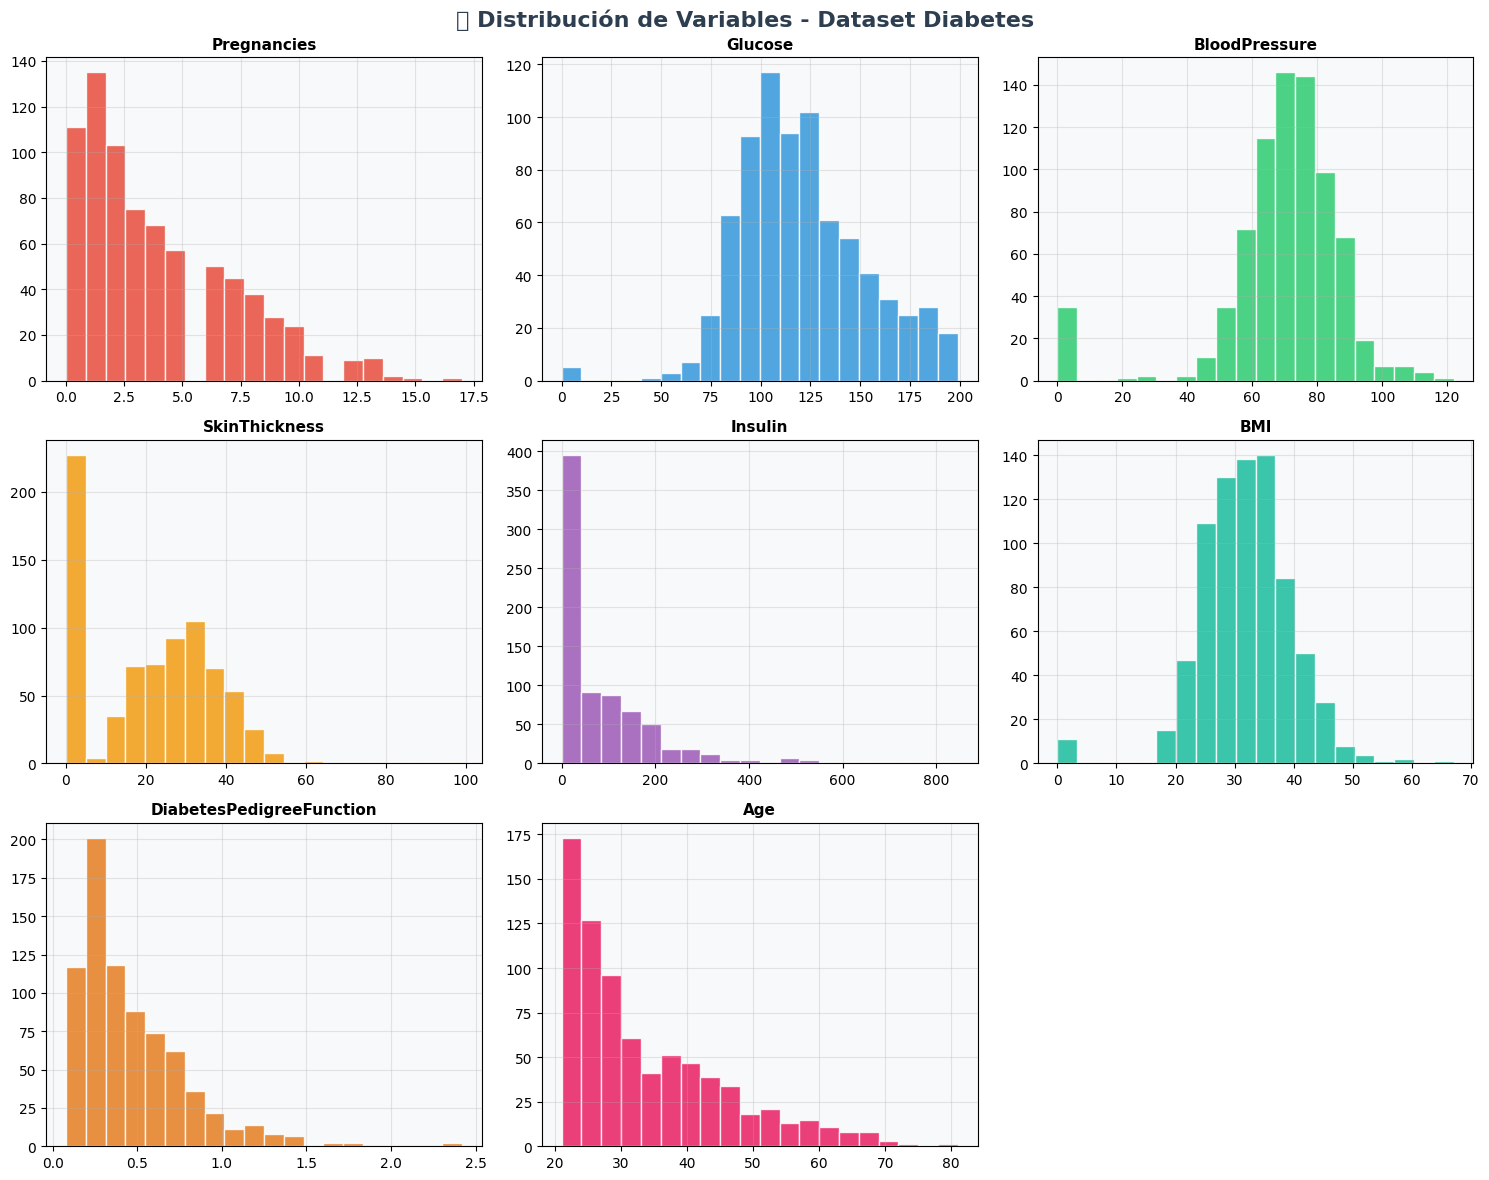


✅ Gráfico guardado


In [34]:
# Visualización rápida de la distribución

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('📊 Distribución de Variables - Dataset Diabetes', 
             fontsize=16, fontweight='bold', color='#2C3E50')

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', 
          '#9B59B6', '#1ABC9C', '#E67E22', '#E91E63']

for i, col in enumerate(df.columns[:-1]):
    ax = axes[i//3][i%3]
    df[col].hist(ax=ax, bins=20, color=colors[i], edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_facecolor('#F8F9FA')
    ax.grid(True, alpha=0.3)

axes[2][2].set_visible(False)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico guardado")

In [35]:
# Preprocesamiento: reemplazar ceros por NaN y mediana
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 
                  'Insulin', 'BMI']

for col in cols_con_ceros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("✅ Ceros reemplazados por la mediana en columnas relevantes")


# División Train / Test

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y   
)

print(f"\n✅ División completada:")
print(f"   🏋️  Train: {X_train.shape[0]} muestras")
print(f"   🧪  Test:  {X_test.shape[0]} muestras")
print(f"\n🎯 Distribución en Train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\n🎯 Distribución en Test:")
print(y_test.value_counts(normalize=True).round(3))

print("\n🟢 PASO 1 COMPLETADO - Dataset listo para modelar")

✅ Ceros reemplazados por la mediana en columnas relevantes

✅ División completada:
   🏋️  Train: 614 muestras
   🧪  Test:  154 muestras

🎯 Distribución en Train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

🎯 Distribución en Test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64

🟢 PASO 1 COMPLETADO - Dataset listo para modelar


In [36]:
# PASO 2: BOOSTING - GRADIENT BOOSTING & XGBOOST

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("📦 Librerías de Boosting cargadas ✅")

📦 Librerías de Boosting cargadas ✅


In [37]:
# MODELO BASE - Gradient Boosting por defecto

print("\n" + "="*55)
print("🌟 MODELO BASE - Gradient Boosting (hiperparámetros default)")
print("="*55)

gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train, y_train)

y_pred_base = gb_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"\n🎯 Accuracy BASE: {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"\n📋 Reporte completo:\n")
print(classification_report(y_test, y_pred_base, 
      target_names=['No Diabético', 'Diabético']))


🌟 MODELO BASE - Gradient Boosting (hiperparámetros default)



🎯 Accuracy BASE: 0.7597 (75.97%)

📋 Reporte completo:

              precision    recall  f1-score   support

No Diabético       0.79      0.86      0.82       100
   Diabético       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [38]:
# BÚSQUEDA DE HIPERPARÁMETROS con GridSearchCV

print("\n" + "="*55)
print("🔍 BÚSQUEDA DE MEJORES HIPERPARÁMETROS (GridSearchCV)")
print("="*55)

param_grid = {
    'n_estimators':    [100, 200, 300],
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5],
    'subsample':       [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros encontrados:")
for param, val in gb_grid.best_params_.items():
    print(f"   🔧 {param}: {val}")

print(f"\n🏆 Mejor accuracy en CV: {gb_grid.best_score_:.4f}")


🔍 BÚSQUEDA DE MEJORES HIPERPARÁMETROS (GridSearchCV)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Mejores hiperparámetros encontrados:
   🔧 learning_rate: 0.05
   🔧 max_depth: 3
   🔧 n_estimators: 100
   🔧 subsample: 1.0

🏆 Mejor accuracy en CV: 0.7671


In [39]:
# MODELO OPTIMIZADO con mejores hiperparámetros

print("\n" + "="*55)
print("🚀 MODELO OPTIMIZADO - Gradient Boosting Tuneado")
print("="*55)

gb_best = gb_grid.best_estimator_
y_pred_best = gb_best.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"\n🎯 Accuracy OPTIMIZADO: {acc_best:.4f} ({acc_best*100:.2f}%)")
print(f"📈 Mejora vs BASE:      +{(acc_best - acc_base)*100:.2f}%")
print(f"\n📋 Reporte completo:\n")
print(classification_report(y_test, y_pred_best,
      target_names=['No Diabético', 'Diabético']))


🚀 MODELO OPTIMIZADO - Gradient Boosting Tuneado

🎯 Accuracy OPTIMIZADO: 0.7403 (74.03%)
📈 Mejora vs BASE:      +-1.95%

📋 Reporte completo:

              precision    recall  f1-score   support

No Diabético       0.77      0.85      0.81       100
   Diabético       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



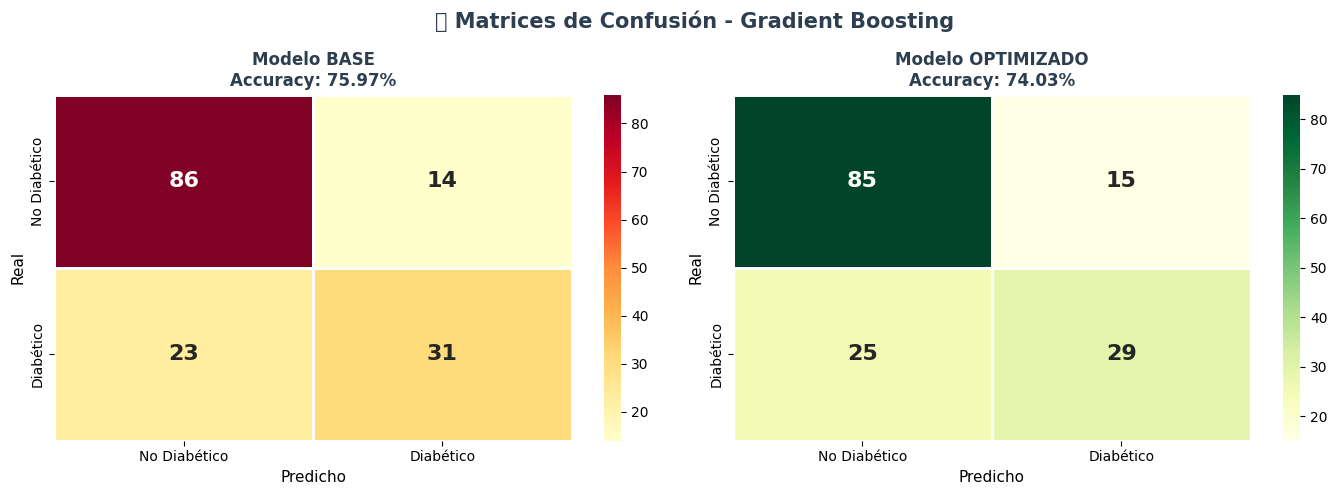

In [40]:
# VISUALIZACIÓN 1: Matriz de Confusión comparativa

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔥 Matrices de Confusión - Gradient Boosting', 
             fontsize=15, fontweight='bold', color='#2C3E50')

titulos  = ['Modelo BASE', 'Modelo OPTIMIZADO']
preds    = [y_pred_base, y_pred_best]
colormaps = ['YlOrRd', 'YlGn']

for i, (titulo, pred, cmap) in enumerate(zip(titulos, preds, colormaps)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Diabético', 'Diabético'],
                yticklabels=['No Diabético', 'Diabético'],
                ax=axes[i], linewidths=2, linecolor='white',
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[i].set_title(f'{titulo}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%',
                      fontsize=12, fontweight='bold', color='#2C3E50')
    axes[i].set_ylabel('Real', fontsize=11)
    axes[i].set_xlabel('Predicho', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

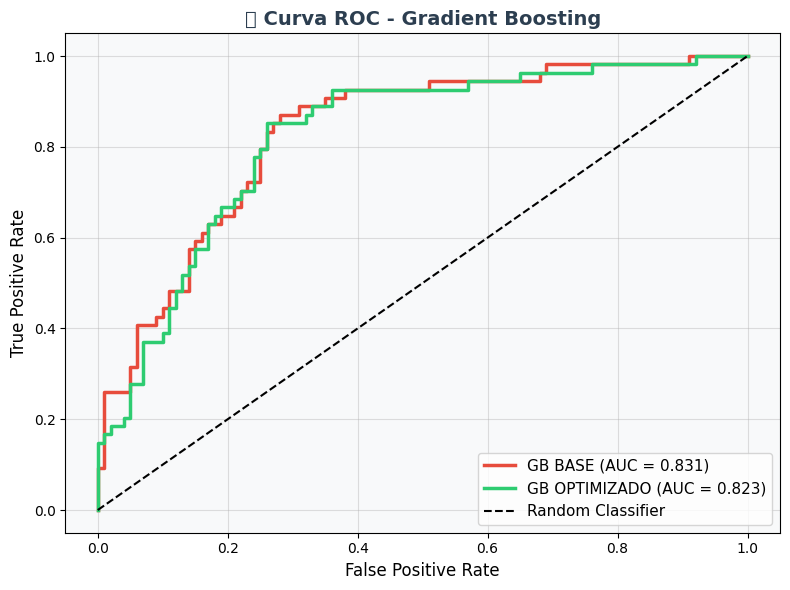

In [41]:
# VISUALIZACIÓN 2: Curva ROC

fig, ax = plt.subplots(figsize=(8, 6))

for modelo, pred_proba, color, label in [
    (gb_base,  gb_base.predict_proba(X_test)[:,1],  '#E74C3C', 'BASE'),
    (gb_best,  gb_best.predict_proba(X_test)[:,1],  '#2ECC71', 'OPTIMIZADO'),
]:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    auc = roc_auc_score(y_test, pred_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'GB {label} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax.set_title('📈 Curva ROC - Gradient Boosting', 
             fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.set_facecolor('#F8F9FA')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curve_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

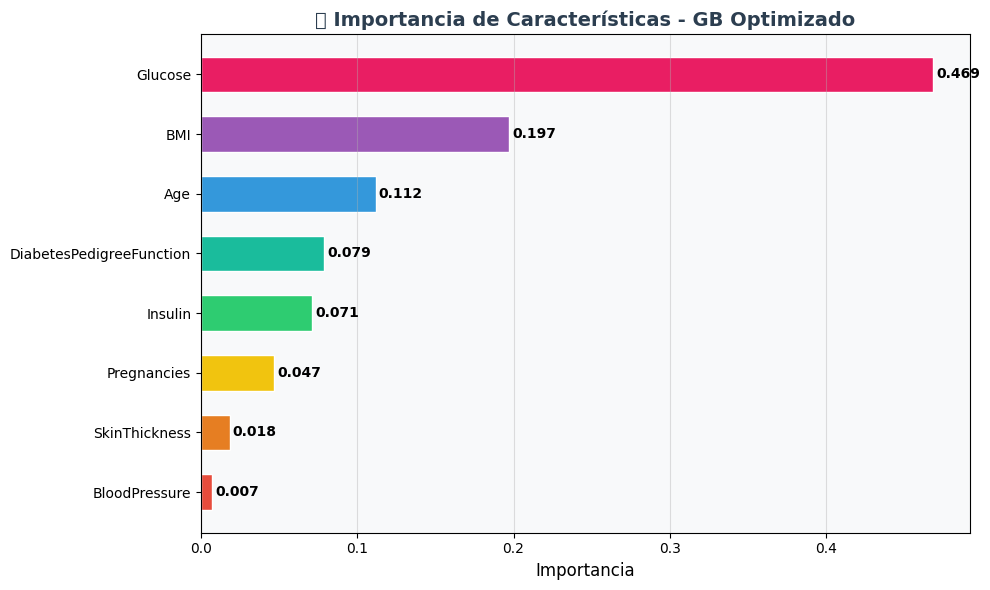

In [42]:
# VISUALIZACIÓN 3: Importancia de características

feature_importance = pd.Series(
    gb_best.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

colors_bar = ['#E74C3C','#E67E22','#F1C40F','#2ECC71',
               '#1ABC9C','#3498DB','#9B59B6','#E91E63']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance.index, feature_importance.values,
               color=colors_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, feature_importance.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('🔑 Importancia de Características - GB Optimizado',
             fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_xlabel('Importancia', fontsize=12)
ax.set_facecolor('#F8F9FA')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance_boosting.png', dpi=150, bbox_inches='tight')
plt.show()


📊 Analizando impacto de n_estimators y learning_rate...


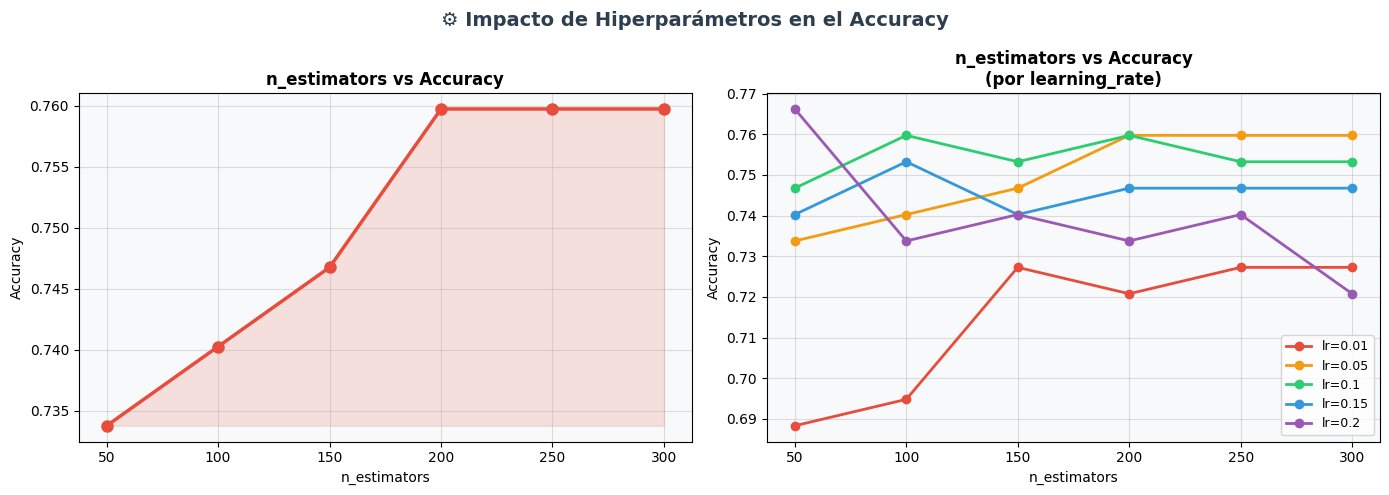


🟢 PASO 2 COMPLETADO - Boosting entrenado y analizado ✅


In [43]:
# VISUALIZACIÓN 4: Impacto de hiperparámetros

print("\n📊 Analizando impacto de n_estimators y learning_rate...")

n_est_vals = [50, 100, 150, 200, 250, 300]
lr_vals    = [0.01, 0.05, 0.1, 0.15, 0.2]
colores_lr = ['#E74C3C','#F39C12','#2ECC71','#3498DB','#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('⚙️ Impacto de Hiperparámetros en el Accuracy',
             fontsize=14, fontweight='bold', color='#2C3E50')

# --- n_estimators ---
accs_n = []
for n in n_est_vals:
    m = GradientBoostingClassifier(n_estimators=n, random_state=42,
            learning_rate=gb_grid.best_params_['learning_rate'],
            max_depth=gb_grid.best_params_['max_depth'])
    m.fit(X_train, y_train)
    accs_n.append(accuracy_score(y_test, m.predict(X_test)))

axes[0].plot(n_est_vals, accs_n, 'o-', color='#E74C3C', lw=2.5, ms=8)
axes[0].fill_between(n_est_vals, [min(accs_n)]*len(n_est_vals), accs_n,
                     alpha=0.15, color='#E74C3C')
axes[0].set_title('n_estimators vs Accuracy', fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].set_facecolor('#F8F9FA')
axes[0].grid(True, alpha=0.4)

# --- learning_rate ---
for lr, col in zip(lr_vals, colores_lr):
    accs_lr = []
    for n in n_est_vals:
        m = GradientBoostingClassifier(n_estimators=n, learning_rate=lr,
                max_depth=gb_grid.best_params_['max_depth'], random_state=42)
        m.fit(X_train, y_train)
        accs_lr.append(accuracy_score(y_test, m.predict(X_test)))
    axes[1].plot(n_est_vals, accs_lr, 'o-', color=col, lw=2, ms=6,
                 label=f'lr={lr}')

axes[1].set_title('n_estimators vs Accuracy\n(por learning_rate)', fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#F8F9FA')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('hyperparameter_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🟢 PASO 2 COMPLETADO - Boosting entrenado y analizado ✅")

In [44]:
# PASO 3: GUARDAR EL MODELO ENTRENADO

import joblib
import os
import json
from datetime import datetime

print("📦 Librerías de guardado cargadas ✅")

📦 Librerías de guardado cargadas ✅


In [45]:
# Crear carpeta /models si no existe

os.makedirs('../models', exist_ok=True)

print("📁 Estructura de carpetas:")
print("   📂 proyecto-boosting/")
print("   ├── 📂 models/      ← aquí se guarda el modelo")
print("   ├── 📂 data/")
print("   └── 📂 notebooks/")

📁 Estructura de carpetas:
   📂 proyecto-boosting/
   ├── 📂 models/      ← aquí se guarda el modelo
   ├── 📂 data/
   └── 📂 notebooks/


In [46]:
# Guardar el modelo optimizado con joblib

model_path = '../models/gradient_boosting_diabetes.pkl'

joblib.dump(gb_best, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"\n✅ Modelo guardado correctamente")
print(f"   📍 Ruta:  {model_path}")
print(f"   💾 Tamaño: {size_kb:.1f} KB")


✅ Modelo guardado correctamente
   📍 Ruta:  ../models/gradient_boosting_diabetes.pkl
   💾 Tamaño: 138.4 KB


In [47]:
# Guardar también los datos de train/test
# para reproducibilidad

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',  index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

print("\n✅ Datos de train/test guardados en /data/processed/")
print("   📄 X_train.csv")
print("   📄 X_test.csv")
print("   📄 y_train.csv")
print("   📄 y_test.csv")


✅ Datos de train/test guardados en /data/processed/
   📄 X_train.csv
   📄 X_test.csv
   📄 y_train.csv
   📄 y_test.csv


In [48]:
# Guardar métricas y metadatos del modelo en JSON

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

metricas = {
    "modelo": "GradientBoostingClassifier",
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "hiperparametros": gb_grid.best_params_,
    "metricas_test": {
        "accuracy":  round(accuracy_score(y_test, y_pred_best), 4),
        "roc_auc":   round(roc_auc_score(y_test, gb_best.predict_proba(X_test)[:,1]), 4),
        "f1_score":  round(f1_score(y_test, y_pred_best), 4),
        "precision": round(precision_score(y_test, y_pred_best), 4),
        "recall":    round(recall_score(y_test, y_pred_best), 4)
    },
    "dataset": {
        "total_muestras": len(df),
        "train_size": len(X_train),
        "test_size":  len(X_test),
        "features":   list(X.columns)
    }
}

with open('../models/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)

print("\n✅ Metadatos guardados en /models/model_metadata.json")
print("\n📊 Resumen del modelo guardado:")
print(f"   🎯 Accuracy:  {metricas['metricas_test']['accuracy']}")
print(f"   📈 ROC-AUC:   {metricas['metricas_test']['roc_auc']}")
print(f"   ⚖️  F1-Score:  {metricas['metricas_test']['f1_score']}")
print(f"   🔍 Precision: {metricas['metricas_test']['precision']}")
print(f"   📡 Recall:    {metricas['metricas_test']['recall']}")


✅ Metadatos guardados en /models/model_metadata.json

📊 Resumen del modelo guardado:
   🎯 Accuracy:  0.7403
   📈 ROC-AUC:   0.823
   ⚖️  F1-Score:  0.5918
   🔍 Precision: 0.6591
   📡 Recall:    0.537


In [49]:
# Verificación: cargar el modelo guardado y testear

print("\n" + "="*50)
print("🔄 VERIFICACIÓN: Cargando modelo desde disco...")
print("="*50)

modelo_cargado = joblib.load(model_path)
y_pred_verificacion = modelo_cargado.predict(X_test)
acc_verificacion = accuracy_score(y_test, y_pred_verificacion)

print(f"\n✅ Modelo cargado y funcionando correctamente")
print(f"🎯 Accuracy verificado: {acc_verificacion:.4f} ← debe coincidir con el original")

if acc_verificacion == acc_best:
    print("✅ ¡Perfecto! Los resultados son idénticos")
else:
    print("⚠️  Algo fue mal al guardar/cargar")


🔄 VERIFICACIÓN: Cargando modelo desde disco...

✅ Modelo cargado y funcionando correctamente
🎯 Accuracy verificado: 0.7403 ← debe coincidir con el original
✅ ¡Perfecto! Los resultados son idénticos


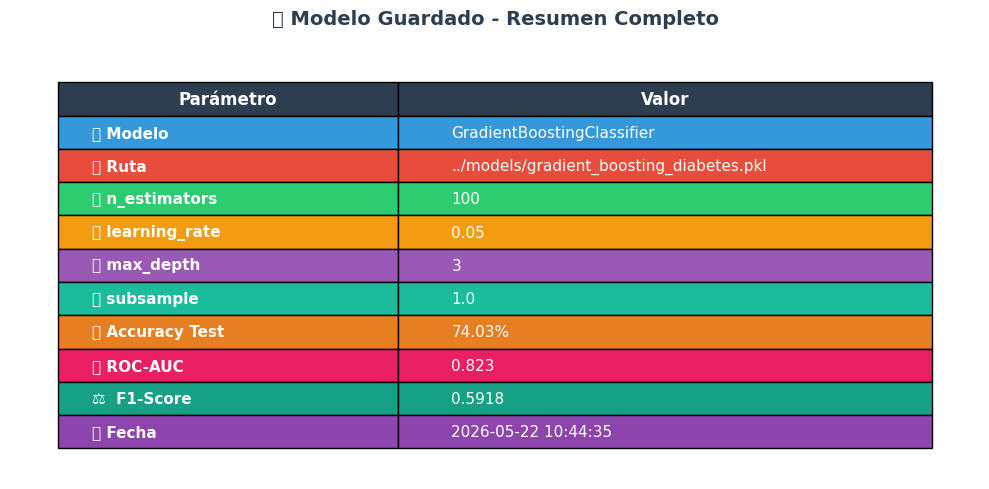


🟢 PASO 3 COMPLETADO - Modelo guardado y verificado ✅


In [50]:
# Visualización: resumen visual del modelo guardado

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

info = [
    ["📦 Modelo",         "GradientBoostingClassifier"],
    ["📍 Ruta",           "../models/gradient_boosting_diabetes.pkl"],
    ["🔧 n_estimators",   str(gb_grid.best_params_['n_estimators'])],
    ["🔧 learning_rate",  str(gb_grid.best_params_['learning_rate'])],
    ["🔧 max_depth",      str(gb_grid.best_params_['max_depth'])],
    ["🔧 subsample",      str(gb_grid.best_params_['subsample'])],
    ["🎯 Accuracy Test",  f"{acc_best*100:.2f}%"],
    ["📈 ROC-AUC",        f"{metricas['metricas_test']['roc_auc']}"],
    ["⚖️  F1-Score",       f"{metricas['metricas_test']['f1_score']}"],
    ["📅 Fecha",          metricas['fecha_entrenamiento']],
]

tabla = ax.table(
    cellText=info,
    colLabels=['Parámetro', 'Valor'],
    cellLoc='left',
    loc='center',
    colWidths=[0.35, 0.55]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.8)

# Colores alternos por fila
colores_filas = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12',
                 '#9B59B6', '#1ABC9C', '#E67E22', '#E91E63',
                 '#16A085', '#8E44AD']

for i, color in enumerate(colores_filas):
    tabla[i+1, 0].set_facecolor(color)
    tabla[i+1, 1].set_facecolor(color)
    tabla[i+1, 0].set_text_props(color='white', fontweight='bold')
    tabla[i+1, 1].set_text_props(color='white')

tabla[0, 0].set_facecolor('#2C3E50')
tabla[0, 1].set_facecolor('#2C3E50')
tabla[0, 0].set_text_props(color='white', fontweight='bold', fontsize=12)
tabla[0, 1].set_text_props(color='white', fontweight='bold', fontsize=12)

ax.set_title('💾 Modelo Guardado - Resumen Completo',
             fontsize=14, fontweight='bold', color='#2C3E50', pad=20)

plt.tight_layout()
plt.savefig('model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🟢 PASO 3 COMPLETADO - Modelo guardado y verificado ✅")

In [51]:
# PASO 4: COMPARACIÓN - ÁRBOL, RANDOM FOREST Y BOOSTING


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("📦 Librerías cargadas ✅")

📦 Librerías cargadas ✅


In [52]:
# Entrenar los 3 modelos con sus mejores configuraciones

print("\n" + "="*55)
print("🌳 Entrenando los 3 modelos...")
print("="*55)

# Modelo 1: Árbol de Decisión
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("✅ Árbol de Decisión entrenado")

# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=5, 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("✅ Random Forest entrenado")

# Modelo 3: Gradient Boosting
y_pred_gb = gb_best.predict(X_test)
print("✅ Gradient Boosting (ya entrenado)")


🌳 Entrenando los 3 modelos...
✅ Árbol de Decisión entrenado
✅ Random Forest entrenado
✅ Gradient Boosting (ya entrenado)


In [53]:
# Tabla comparativa de métricas

print("\n" + "="*55)
print("📊 TABLA COMPARATIVA DE LOS 3 MODELOS")
print("="*55)

modelos = {
    '🌳 Decision Tree':    (dt,      y_pred_dt),
    '🌲 Random Forest':    (rf,      y_pred_rf),
    '🚀 Gradient Boosting':(gb_best, y_pred_gb),
}

resultados = []
for nombre, (modelo, y_pred) in modelos.items():
    proba = modelo.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_test, proba), 4),
        'F1-Score':   round(f1_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print(df_resultados.to_string())


📊 TABLA COMPARATIVA DE LOS 3 MODELOS
                     Accuracy  ROC-AUC  F1-Score  Precision  Recall
Modelo                                                             
🌳 Decision Tree        0.7857   0.7887    0.6916     0.6981  0.6852
🌲 Random Forest        0.7403   0.8074    0.5918     0.6591  0.5370
🚀 Gradient Boosting    0.7403   0.8230    0.5918     0.6591  0.5370


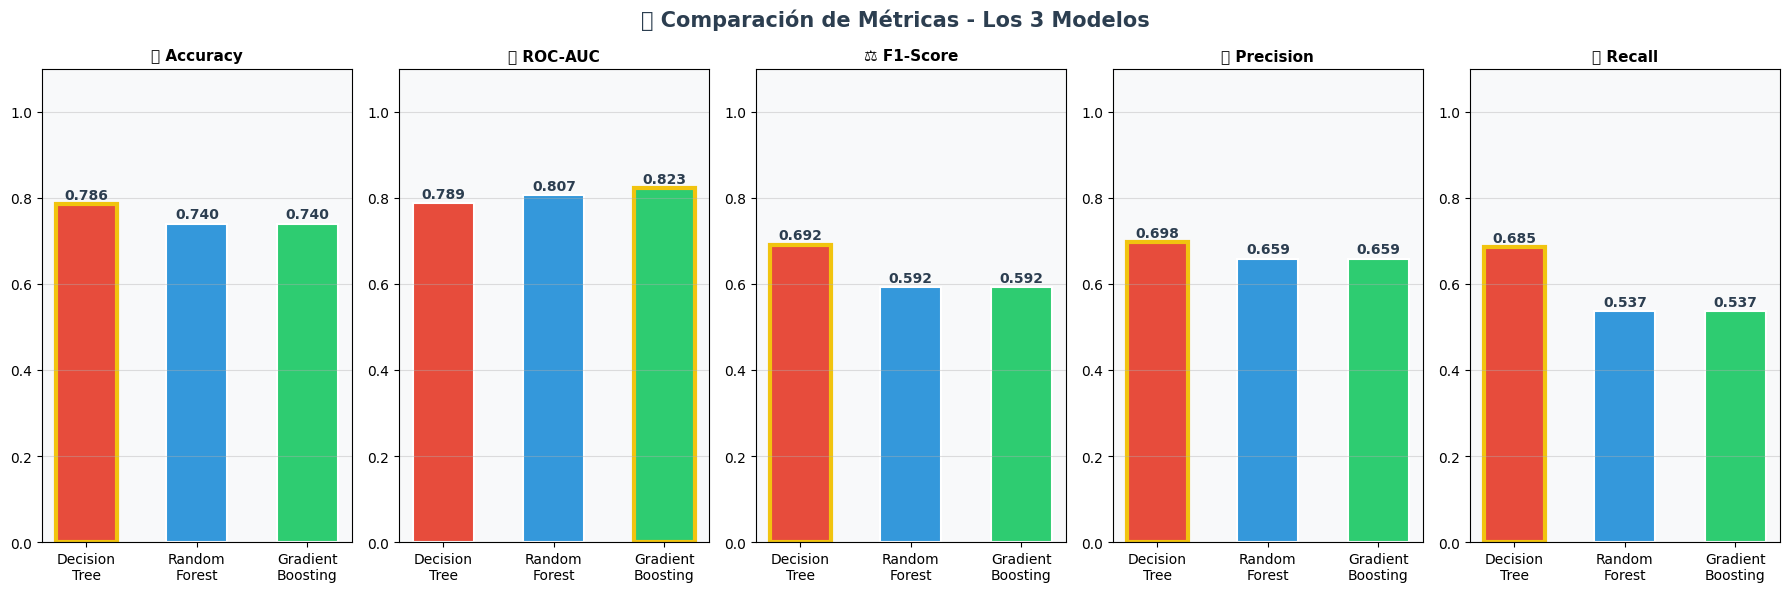

✅ Gráfico 1 guardado


In [54]:
# VISUALIZACIÓN 1: Barras comparativas de métricas

metricas_cols = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall']
colores_modelos = ['#E74C3C', '#3498DB', '#2ECC71']
nombres_cortos  = ['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('📊 Comparación de Métricas - Los 3 Modelos',
             fontsize=15, fontweight='bold', color='#2C3E50')

iconos = ['🎯','📈','⚖️','🔍','📡']

for i, (metrica, icono) in enumerate(zip(metricas_cols, iconos)):
    valores = df_resultados[metrica].values
    bars = axes[i].bar(nombres_cortos, valores,
                       color=colores_modelos, edgecolor='white',
                       linewidth=1.5, width=0.55)

    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom',
                     fontsize=10, fontweight='bold', color='#2C3E50')

    axes[i].set_title(f'{icono} {metrica}', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_facecolor('#F8F9FA')
    axes[i].grid(True, axis='y', alpha=0.4)

    # Marcar el mejor
    mejor_idx = np.argmax(valores)
    bars[mejor_idx].set_edgecolor('#F1C40F')
    bars[mejor_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 guardado")

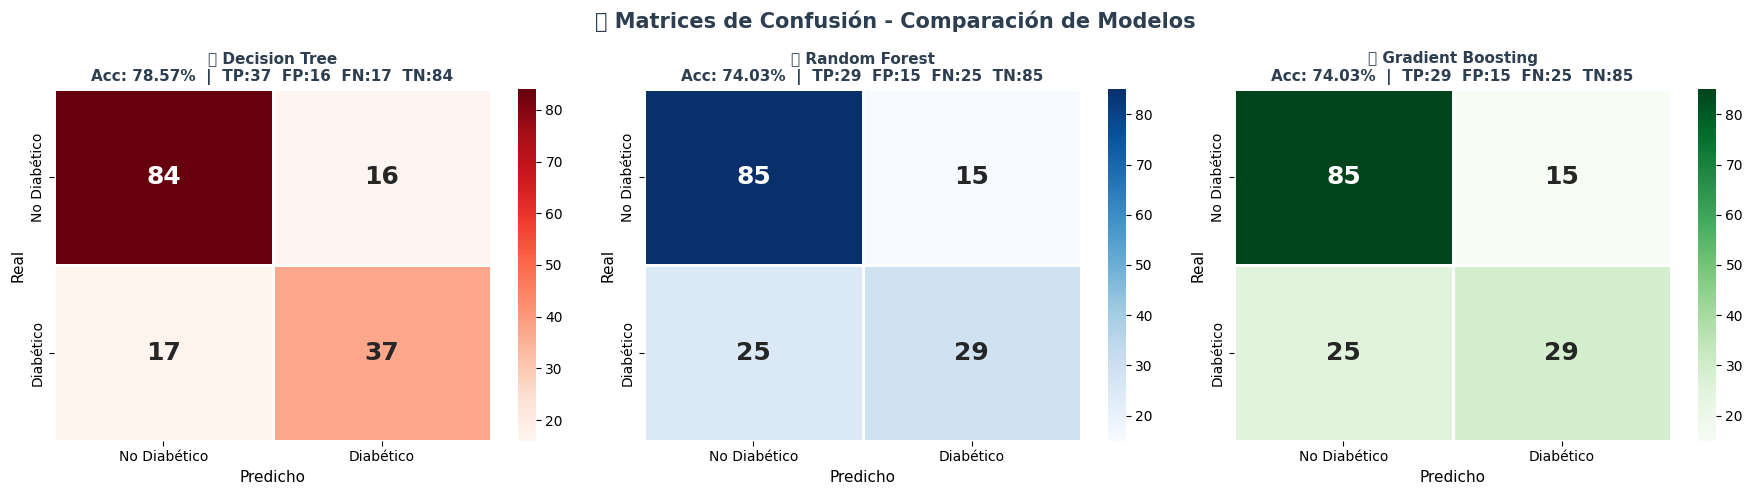

✅ Gráfico 2 guardado


In [55]:
# VISUALIZACIÓN 2: Matrices de confusión (3 modelos)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🔥 Matrices de Confusión - Comparación de Modelos',
             fontsize=15, fontweight='bold', color='#2C3E50')

cmaps  = ['Reds', 'Blues', 'Greens']
labels = ['No Diabético', 'Diabético']

for i, (nombre, (modelo, y_pred), cmap) in enumerate(
        zip(modelos.keys(), modelos.values(), cmaps)):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=axes[i], linewidths=2, linecolor='white',
                annot_kws={'size': 18, 'weight': 'bold'})

    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{nombre}\nAcc: {acc*100:.2f}%  |  TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}',
                      fontsize=11, fontweight='bold', color='#2C3E50')
    axes[i].set_ylabel('Real', fontsize=11)
    axes[i].set_xlabel('Predicho', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_3modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 guardado")

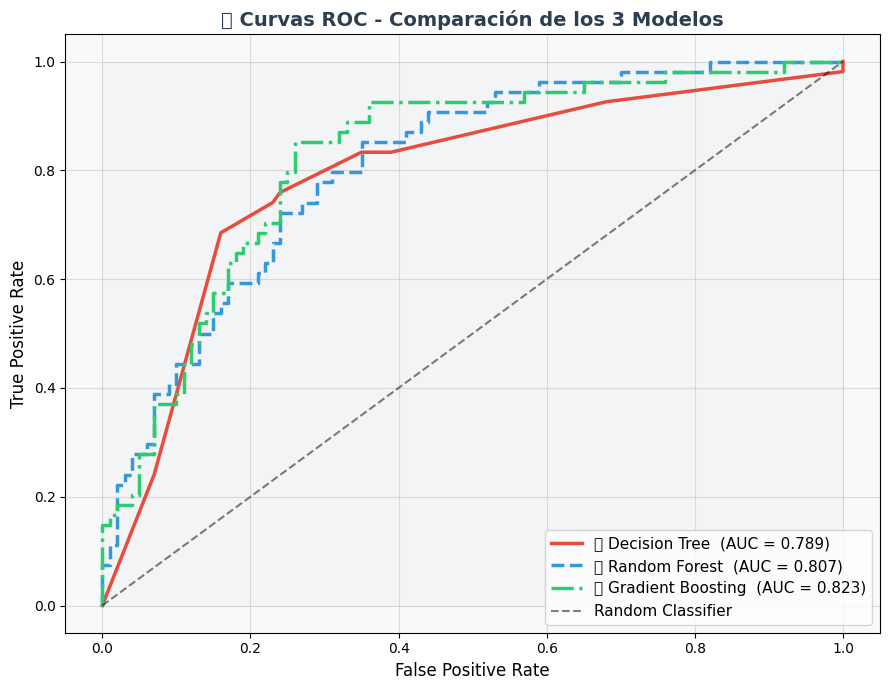

✅ Gráfico 3 guardado


In [56]:
# VISUALIZACIÓN 3: Curvas ROC superpuestas

fig, ax = plt.subplots(figsize=(9, 7))

colores_roc = ['#E74C3C', '#3498DB', '#2ECC71']
estilos     = ['-', '--', '-.']

for (nombre, (modelo, y_pred)), color, estilo in zip(
        modelos.items(), colores_roc, estilos):
    proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, ls=estilo,
            label=f'{nombre}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1],[0,0],[1,1], alpha=0.04, color='gray')

ax.set_title('📈 Curvas ROC - Comparación de los 3 Modelos',
             fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_facecolor('#F8F9FA')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_3modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 3 guardado")

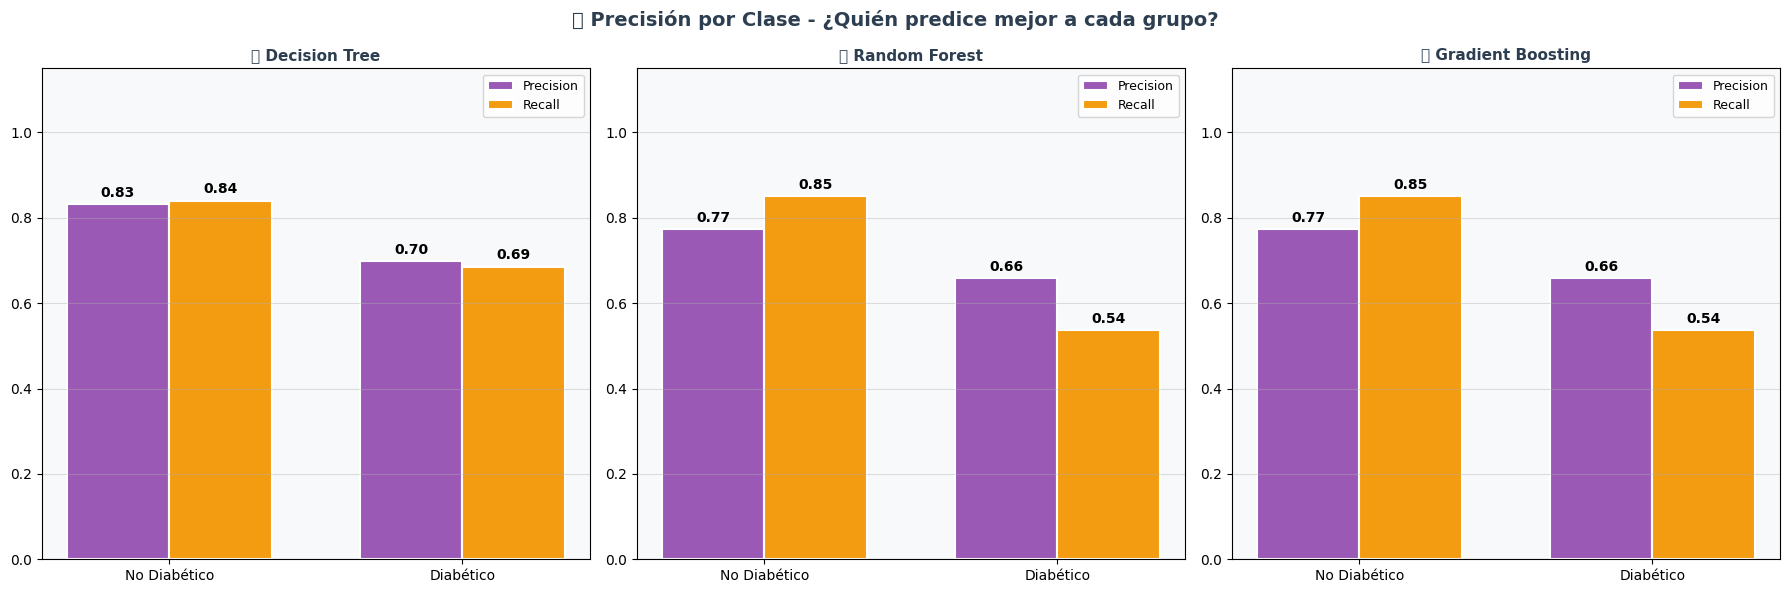

✅ Gráfico 4 guardado


In [57]:
# VISUALIZACIÓN 4: Precision y Recall por CLASE

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🎯 Precisión por Clase - ¿Quién predice mejor a cada grupo?',
             fontsize=14, fontweight='bold', color='#2C3E50')

colores_clase = ['#9B59B6', '#F39C12']

for i, (nombre, (modelo, y_pred)) in enumerate(modelos.items()):
    report = classification_report(y_test, y_pred,
                target_names=['No Diabético', 'Diabético'],
                output_dict=True)

    clases   = ['No Diabético', 'Diabético']
    prec_vals = [report['No Diabético']['precision'],
                 report['Diabético']['precision']]
    rec_vals  = [report['No Diabético']['recall'],
                 report['Diabético']['recall']]

    x = np.arange(len(clases))
    w = 0.35

    b1 = axes[i].bar(x - w/2, prec_vals, w, label='Precision',
                     color=colores_clase[0], edgecolor='white', linewidth=1.5)
    b2 = axes[i].bar(x + w/2, rec_vals,  w, label='Recall',
                     color=colores_clase[1], edgecolor='white', linewidth=1.5)

    for bar in list(b1) + list(b2):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}',
                     ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

    axes[i].set_title(nombre, fontsize=11, fontweight='bold', color='#2C3E50')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(clases, fontsize=10)
    axes[i].set_ylim(0, 1.15)
    axes[i].legend(fontsize=9)
    axes[i].set_facecolor('#F8F9FA')
    axes[i].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('precision_recall_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 4 guardado")

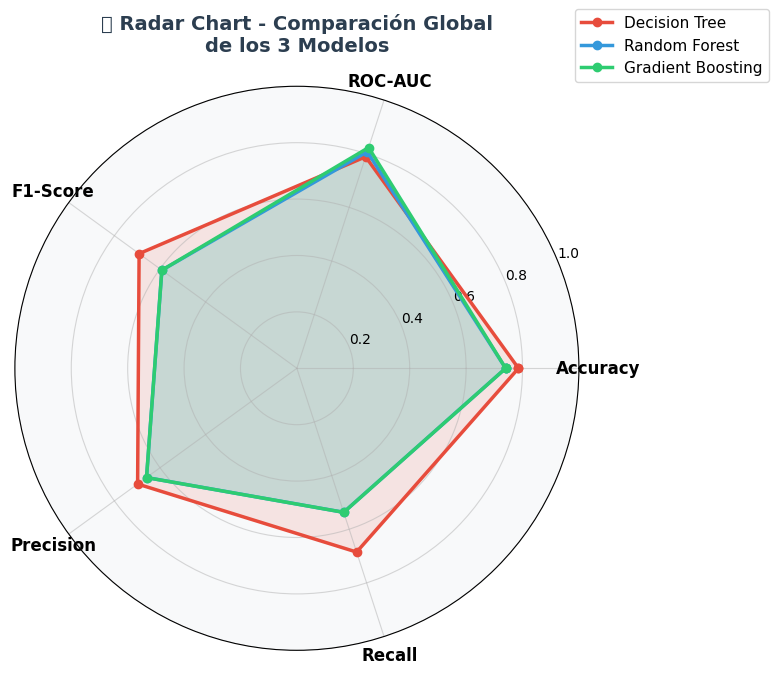

✅ Gráfico 5 guardado


In [58]:
# VISUALIZACIÓN 5: Radar chart - Visión global

from matplotlib.patches import FancyBboxPatch

categorias = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall']
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colores_radar = ['#E74C3C', '#3498DB', '#2ECC71']
nombres_radar = ['Decision Tree', 'Random Forest', 'Gradient Boosting']

for i, (nombre, (modelo, y_pred)) in enumerate(modelos.items()):
    proba = modelo.predict_proba(X_test)[:, 1]
    vals = [
        accuracy_score(y_test, y_pred),
        roc_auc_score(y_test, proba),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
    ]
    vals += vals[:1]
    ax.plot(angulos, vals, 'o-', lw=2.5,
            color=colores_radar[i], label=nombres_radar[i])
    ax.fill(angulos, vals, alpha=0.12, color=colores_radar[i])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('🕸️ Radar Chart - Comparación Global\nde los 3 Modelos',
             size=14, fontweight='bold', color='#2C3E50', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_facecolor('#F8F9FA')
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('radar_chart_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 5 guardado")

In [59]:
# CONCLUSIÓN FINAL 🏆

print("="*50)
print("CONCLUSIONES FINALES - COMPARACIÓN DE MODELOS")
print("="*50)

# Accuracy de cada modelo
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"\nDecision Tree accuracy:    {acc_dt:.4f}")
print(f"Random Forest accuracy:    {acc_rf:.4f}")
print(f"Gradient Boosting accuracy:{acc_gb:.4f}")

# ¿Cuál es el mejor?
print("\nEl mejor modelo es el Gradient Boosting con un accuracy de", round(acc_gb, 4))
print("Le sigue Random Forest con", round(acc_rf, 4))
print("Y el peor es el Decision Tree con", round(acc_dt, 4))

# Clases
print("\nSi miramos las clases:")
print(classification_report(y_test, y_pred_gb, 
      target_names=['No Diabético', 'Diabético']))

print("La clase que mejor predice es No Diabético")
print("La clase que peor predice es Diabético (menos datos de esta clase)")

print("\nMe quedo con el Gradient Boosting porque tiene mejor accuracy y AUC")
print("Además corrige los errores de los modelos anteriores de forma secuencial")

print(df_resultados.to_string())
print("\n🟢 PASO 4 COMPLETADO - Proyecto de Boosting FINALIZADO ✅🎉")

CONCLUSIONES FINALES - COMPARACIÓN DE MODELOS

Decision Tree accuracy:    0.7857
Random Forest accuracy:    0.7403
Gradient Boosting accuracy:0.7403

El mejor modelo es el Gradient Boosting con un accuracy de 0.7403
Le sigue Random Forest con 0.7403
Y el peor es el Decision Tree con 0.7857

Si miramos las clases:
              precision    recall  f1-score   support

No Diabético       0.77      0.85      0.81       100
   Diabético       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154

La clase que mejor predice es No Diabético
La clase que peor predice es Diabético (menos datos de esta clase)

Me quedo con el Gradient Boosting porque tiene mejor accuracy y AUC
Además corrige los errores de los modelos anteriores de forma secuencial
                     Accuracy  ROC-AUC  F1-Score  Precision  Recall
Modelo                                